In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import plotly.express as px

C:\Users\LJENG\AppData\Roaming\Python\Python38\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("auto-mpg.csv")
df
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [3]:
df["horsepower"]=df["horsepower"].replace("?",df[df['horsepower']!='?']['horsepower'].astype("int").mean())

In [4]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [5]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

In [6]:
df.horsepower.unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', 104.46938775510205, '100', '105', '175',
       '153', '180', '110', '72', '86', '70', '76', '65', '69', '60',
       '80', '54', '208', '155', '112', '92', '145', '137', '158', '167',
       '94', '107', '230', '49', '75', '91', '122', '67', '83', '78',
       '52', '61', '93', '148', '129', '96', '71', '98', '115', '53',
       '81', '79', '120', '152', '102', '108', '68', '58', '149', '89',
       '63', '48', '66', '139', '103', '125', '133', '138', '135', '142',
       '77', '62', '132', '84', '64', '74', '116', '82'], dtype=object)

In [7]:
df['horsepower']=df['horsepower'].astype('int')

In [8]:
df.horsepower.unique()

array([130, 165, 150, 140, 198, 220, 215, 225, 190, 170, 160,  95,  97,
        85,  88,  46,  87,  90, 113, 200, 210, 193, 104, 100, 105, 175,
       153, 180, 110,  72,  86,  70,  76,  65,  69,  60,  80,  54, 208,
       155, 112,  92, 145, 137, 158, 167,  94, 107, 230,  49,  75,  91,
       122,  67,  83,  78,  52,  61,  93, 148, 129,  96,  71,  98, 115,
        53,  81,  79, 120, 152, 102, 108,  68,  58, 149,  89,  63,  48,
        66, 139, 103, 125, 133, 138, 135, 142,  77,  62, 132,  84,  64,
        74, 116,  82])

In [9]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower        int32
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

In [15]:
df.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
mpg,1.000000,-0.775396,-0.804203,-0.771543,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.839061,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.893760,0.932824,-0.543684,-0.370164,-0.609409
horsepower,-0.771543,0.839061,0.893760,1.000000,0.860676,-0.684376,-0.411750,-0.453613
weight,-0.831741,0.896017,0.932824,0.860676,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.684376,-0.417457,1.000000,0.288137,0.205873
model year,0.579267,-0.348746,-0.370164,-0.411750,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.453613,-0.581024,0.205873,0.180662,1.000000


<AxesSubplot:>

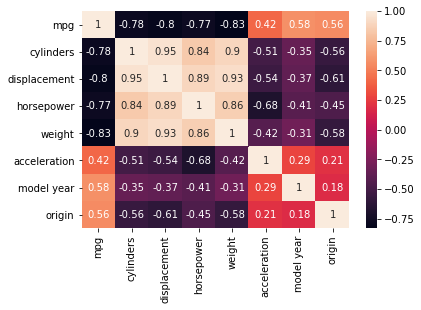

In [20]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<AxesSubplot:>

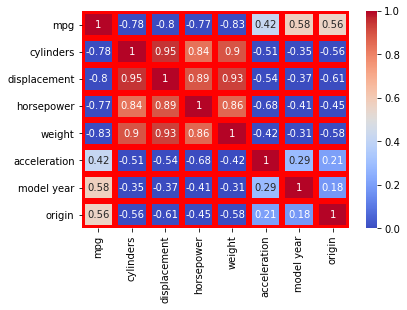

In [26]:
sns.heatmap(df.corr(numeric_only=True),annot=True,vmin=0,linewidths=5,linecolor='red',cmap='coolwarm')

<AxesSubplot:>

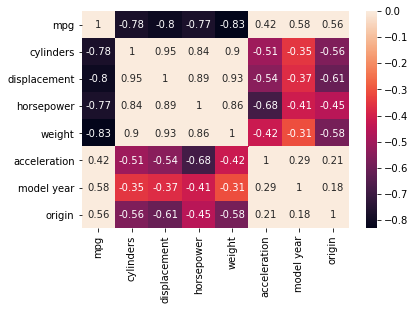

In [24]:
sns.heatmap(df.corr(numeric_only=True),annot=True,vmax=0)

<AxesSubplot:xlabel='horsepower', ylabel='weight'>

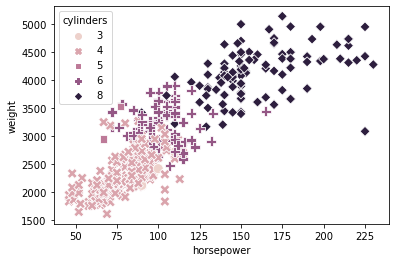

In [36]:
sns.scatterplot(data=df,x='horsepower',y='weight',hue='cylinders',style='cylinders',s=100)

In [38]:
pip install plotly

In [2]:
df1 = pd.read_csv("social_media_engagement.csv")
df1

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive
...,...,...,...,...,...,...,...,...,...
95,96,Instagram,carousel,7/12/2023 17:45,36,294,911,Wednesday,positive
96,97,Twitter,video,10/27/2023 23:45,314,108,458,Friday,neutral
97,98,Twitter,text,8/5/2023 8:45,229,179,38,Saturday,positive
98,99,Instagram,poll,12/29/2023 12:15,5000,500,204,Friday,positive


In [4]:
df1.head()

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive


In [6]:
df1.tail()

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
95,96,Instagram,carousel,7/12/2023 17:45,36,294,911,Wednesday,positive
96,97,Twitter,video,10/27/2023 23:45,314,108,458,Friday,neutral
97,98,Twitter,text,8/5/2023 8:45,229,179,38,Saturday,positive
98,99,Instagram,poll,12/29/2023 12:15,5000,500,204,Friday,positive
99,100,Instagram,image,6/6/2023 21:00,4483,357,25,Tuesday,neutral


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   post_id          100 non-null    int64 
 1   platform         100 non-null    object
 2   post_type        100 non-null    object
 3   post_time        100 non-null    object
 4   likes            100 non-null    int64 
 5   comments         100 non-null    int64 
 6   shares           100 non-null    int64 
 7   post_day         100 non-null    object
 8   sentiment_score  100 non-null    object
dtypes: int64(4), object(5)
memory usage: 7.2+ KB


In [8]:
df1.describe()

,post_id,likes,comments,shares
count,100.000000,100.000000,100.00000,100.000000
mean,50.500000,2381.810000,202.66000,415.650000
std,29.011492,1632.573284,138.84067,283.877601
min,1.000000,15.000000,10.00000,16.000000
25%,25.750000,895.750000,89.75000,183.000000
50%,50.500000,2220.000000,171.00000,356.500000
75%,75.250000,3593.250000,299.00000,689.500000
max,100.000000,5000.000000,500.00000,993.000000


In [10]:
df1.isna().sum()

post_id            0
platform           0
post_type          0
post_time          0
likes              0
comments           0
shares             0
post_day           0
sentiment_score    0
dtype: int64

In [11]:
df1.dtypes

post_id             int64
platform           object
post_type          object
post_time          object
likes               int64
comments            int64
shares              int64
post_day           object
sentiment_score    object
dtype: object

In [17]:
df1.platform.unique()

array(['Facebook', 'Instagram', 'Twitter'], dtype=object)

In [18]:
df1.post_type.unique()

array(['image', 'carousel', 'poll', 'video', 'text'], dtype=object)

In [19]:
df1.sentiment_score.unique()

array(['positive', 'neutral', 'negative'], dtype=object)

In [42]:
df1.groupby('platform')[['likes','comments']].sum()

,likes,comments
platform,,
Facebook,86392,7965
Instagram,107994,8368
Twitter,43795,3933


In [47]:
x = df1.groupby("platform")["likes"].sum().apply(lambda x : "good" if x>50000 else "verygood")

In [48]:
x

platform
Facebook         good
Instagram        good
Twitter      verygood
Name: likes, dtype: object

In [49]:
df1.groupby('platform').head()

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive
5,6,Instagram,carousel,5/5/2023 20:00,256,186,211,Friday,neutral
6,7,Instagram,image,2/26/2023 11:45,1982,30,906,Sunday,positive
7,8,Instagram,text,10/28/2023 19:30,1274,45,216,Saturday,neutral
8,9,Facebook,video,5/2/2023 6:15,317,249,221,Tuesday,neutral
9,10,Twitter,carousel,5/11/2023 11:00,1878,225,438,Thursday,neutral


In [50]:
df1.groupby("platform",sort=True).sample()

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
84,85,Facebook,text,7/6/2023 7:00,2566,368,304,Thursday,neutral
5,6,Instagram,carousel,5/5/2023 20:00,256,186,211,Friday,neutral
37,38,Twitter,poll,5/2/2023 0:30,2463,187,445,Tuesday,positive


In [51]:
df1.describe()

,post_id,likes,comments,shares
count,100.000000,100.000000,100.00000,100.000000
mean,50.500000,2381.810000,202.66000,415.650000
std,29.011492,1632.573284,138.84067,283.877601
min,1.000000,15.000000,10.00000,16.000000
25%,25.750000,895.750000,89.75000,183.000000
50%,50.500000,2220.000000,171.00000,356.500000
75%,75.250000,3593.250000,299.00000,689.500000
max,100.000000,5000.000000,500.00000,993.000000


In [53]:
df1.groupby('platform').size()

platform
Facebook     32
Instagram    36
Twitter      32
dtype: int64

In [55]:
df1.shape

(100, 9)

In [56]:
df1.groupby('platform').groups

{'Facebook': [0, 1, 8, 12, 14, 19, 25, 27, 28, 29, 30, 35, 36, 38, 46, 47, 57, 61, 65, 66, 69, 71, 72, 74, 79, 80, 83, 84, 87, 90, 91, 93], 'Instagram': [2, 5, 6, 7, 16, 23, 26, 31, 34, 39, 41, 43, 45, 49, 53, 55, 56, 59, 60, 63, 64, 67, 70, 73, 75, 77, 78, 81, 82, 86, 89, 92, 94, 95, 98, 99], 'Twitter': [3, 4, 9, 10, 11, 13, 15, 17, 18, 20, 21, 22, 24, 32, 33, 37, 40, 42, 44, 48, 50, 51, 52, 54, 58, 62, 68, 76, 85, 88, 96, 97]}

In [57]:
for i,j in df1.groupby('platform'):
    print(i,"name")
    print(j,"data")

Facebook name
    post_id  platform post_type         post_time  likes  comments  shares  \
0         1  Facebook     image   8/17/2023 14:45   2121       474     628   
1         2  Facebook  carousel    5/14/2023 0:45   3660       432     694   
8         9  Facebook     video     5/2/2023 6:15    317       249     221   
12       13  Facebook  carousel  11/11/2023 15:45     45        78     375   
14       15  Facebook  carousel    1/9/2023 20:00    889       314     262   
19       20  Facebook     image    2/2/2023 16:00    455        86      79   
25       26  Facebook  carousel    10/5/2023 6:30   1992        70     515   
27       28  Facebook      poll     3/1/2023 8:00   2083       500     388   
28       29  Facebook     image    1/7/2023 10:30    548       153     731   
29       30  Facebook  carousel     2/3/2023 0:30   4594       216     739   
30       31  Facebook      poll   9/10/2023 13:45   4795       449     978   
35       36  Facebook     video    4/8/2023 19:15 

In [58]:
df1.groupby('platform').nth(0)

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative


In [2]:
df2 = pd.read_csv('ipl-matches.csv')
df2

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


In [5]:
df2.Team1.unique()

array(['Rajasthan Royals', 'Royal Challengers Bangalore',
       'Sunrisers Hyderabad', 'Delhi Capitals', 'Chennai Super Kings',
       'Gujarat Titans', 'Lucknow Super Giants', 'Kolkata Knight Riders',
       'Punjab Kings', 'Mumbai Indians', 'Kings XI Punjab',
       'Delhi Daredevils', 'Rising Pune Supergiant', 'Gujarat Lions',
       'Rising Pune Supergiants', 'Pune Warriors', 'Deccan Chargers',
       'Kochi Tuskers Kerala'], dtype=object)

In [10]:
df2[((df2["Team1"]=="Mumbai Indians") | (df2["Team2"]=="Mumbai Indians"))&(df2['WinningTeam']!="Mumbai Indians")]

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
9,1304111,Mumbai,2022-05-17,2022,65,Sunrisers Hyderabad,Mumbai Indians,"Wankhede Stadium, Mumbai",Mumbai Indians,field,N,Sunrisers Hyderabad,Runs,3.0,NaN,RA Tripathi,"['Abhishek Sharma', 'PK Garg', 'RA Tripathi', ...","['RG Sharma', 'Ishan Kishan', 'DR Sams', 'Tila...",CB Gaffaney,N Pandit
18,1304102,Navi Mumbai,2022-05-09,2022,56,Kolkata Knight Riders,Mumbai Indians,"Dr DY Patil Sports Academy, Mumbai",Mumbai Indians,field,N,Kolkata Knight Riders,Runs,52.0,NaN,JJ Bumrah,"['VR Iyer', 'AM Rahane', 'N Rana', 'SS Iyer', ...","['RG Sharma', 'Ishan Kishan', 'Tilak Varma', '...",CB Gaffaney,GR Sadashiv Iyer
37,1304083,Mumbai,2022-04-24,2022,37,Lucknow Super Giants,Mumbai Indians,"Wankhede Stadium, Mumbai",Mumbai Indians,field,N,Lucknow Super Giants,Runs,36.0,NaN,KL Rahul,"['Q de Kock', 'KL Rahul', 'MK Pandey', 'MP Sto...","['Ishan Kishan', 'RG Sharma', 'D Brevis', 'SA ...",M Erasmus,HAS Khalid
41,1304079,Navi Mumbai,2022-04-21,2022,33,Mumbai Indians,Chennai Super Kings,"Dr DY Patil Sports Academy, Mumbai",Chennai Super Kings,field,N,Chennai Super Kings,Wickets,3.0,NaN,Mukesh Choudhary,"['RG Sharma', 'Ishan Kishan', 'D Brevis', 'SA ...","['RD Gaikwad', 'RV Uthappa', 'MJ Santner', 'AT...",BNJ Oxenford,UV Gandhe
48,1304072,Mumbai,2022-04-16,2022,26,Lucknow Super Giants,Mumbai Indians,"Brabourne Stadium, Mumbai",Mumbai Indians,field,N,Lucknow Super Giants,Runs,18.0,NaN,KL Rahul,"['KL Rahul', 'Q de Kock', 'MK Pandey', 'MP Sto...","['Ishan Kishan', 'RG Sharma', 'D Brevis', 'SA ...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,336028,Mumbai,2008-05-21,2007/08,45,Mumbai Indians,Kings XI Punjab,Wankhede Stadium,Mumbai Indians,field,N,Kings XI Punjab,Runs,1.0,NaN,SE Marsh,"['ST Jayasuriya', 'SR Tendulkar', 'DR Smith', ...","['SE Marsh', 'JR Hopes', 'LA Pomersbach', 'Yuv...",BF Bowden,GA Pratapkumar
937,335994,Mumbai,2008-04-27,2007/08,14,Mumbai Indians,Deccan Chargers,Dr DY Patil Sports Academy,Deccan Chargers,field,N,Deccan Chargers,Wickets,10.0,NaN,AC Gilchrist,"['L Ronchi', 'ST Jayasuriya', 'AM Rahane', 'RV...","['AC Gilchrist', 'VVS Laxman', 'A Symonds', 'R...",Asad Rauf,SL Shastri
940,335991,Chandigarh,2008-04-25,2007/08,10,Kings XI Punjab,Mumbai Indians,"Punjab Cricket Association Stadium, Mohali",Mumbai Indians,field,N,Kings XI Punjab,Runs,66.0,NaN,KC Sangakkara,"['K Goel', 'IK Pathan', 'KC Sangakkara', 'Yuvr...","['L Ronchi', 'ST Jayasuriya', 'RV Uthappa', 'D...",Aleem Dar,AM Saheba
942,335989,Chennai,2008-04-23,2007/08,8,Chennai Super Kings,Mumbai Indians,"MA Chidambaram Stadium, Chepauk",Mumbai Indians,field,N,Chennai Super Kings,Runs,6.0,NaN,ML Hayden,"['PA Patel', 'ML Hayden', 'MEK Hussey', 'SK Ra...","['L Ronchi', 'ST Jayasuriya', 'RV Uthappa', 'S...",DJ Harper,GA Pratapkumar


In [19]:

df2[((df2["Team1"]=="Mumbai Indians") | (df2["Team2"]=="Mumbai Indians"))&(df2['WinningTeam']!="Mumbai Indians")].Player_of_Match.value_counts()

Player_of_Match
SPD Smith     4
KL Rahul      4
SK Raina      4
JH Kallis     3
CH Gayle      3
             ..
JJ Bumrah     1
AJ Finch      1
SS Iyer       1
GJ Bailey     1
MV Boucher    1
Name: count, Length: 68, dtype: int64

In [23]:
df2[df2["SuperOver"]=="Y"]

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
114,1254077,Chennai,2021-04-25,2021,20,Delhi Capitals,Sunrisers Hyderabad,"MA Chidambaram Stadium, Chepauk, Chennai",Delhi Capitals,bat,Y,Delhi Capitals,SuperOver,NaN,NaN,PP Shaw,"['PP Shaw', 'S Dhawan', 'RR Pant', 'SPD Smith'...","['DA Warner', 'JM Bairstow', 'KS Williamson', ...",CB Gaffaney,KN Ananthapadmanabhan
158,1216512,Abu Dhabi,2020-10-18,2020/21,35,Kolkata Knight Riders,Sunrisers Hyderabad,Sheikh Zayed Stadium,Sunrisers Hyderabad,field,Y,Kolkata Knight Riders,SuperOver,NaN,NaN,LH Ferguson,"['Shubman Gill', 'RA Tripathi', 'N Rana', 'AD ...","['JM Bairstow', 'KS Williamson', 'PK Garg', 'D...",PG Pathak,S Ravi
159,1216517,NaN,2020-10-18,2020/21,36,Mumbai Indians,Kings XI Punjab,Dubai International Cricket Stadium,Mumbai Indians,bat,Y,Kings XI Punjab,SuperOver,NaN,NaN,KL Rahul,"['RG Sharma', 'Q de Kock', 'SA Yadav', 'Ishan ...","['KL Rahul', 'MA Agarwal', 'CH Gayle', 'N Poor...",Nitin Menon,PR Reiffel
184,1216547,NaN,2020-09-28,2020/21,10,Royal Challengers Bangalore,Mumbai Indians,Dubai International Cricket Stadium,Mumbai Indians,field,Y,Royal Challengers Bangalore,SuperOver,NaN,NaN,AB de Villiers,"['D Padikkal', 'AJ Finch', 'V Kohli', 'AB de V...","['RG Sharma', 'Q de Kock', 'SA Yadav', 'Ishan ...",Nitin Menon,PR Reiffel
192,1216493,NaN,2020-09-20,2020/21,2,Delhi Capitals,Kings XI Punjab,Dubai International Cricket Stadium,Kings XI Punjab,field,Y,Delhi Capitals,SuperOver,NaN,NaN,MP Stoinis,"['PP Shaw', 'S Dhawan', 'SO Hetmyer', 'SS Iyer...","['KL Rahul', 'MA Agarwal', 'KK Nair', 'N Poora...",AK Chaudhary,Nitin Menon
203,1178426,Mumbai,2019-05-02,2019,51,Mumbai Indians,Sunrisers Hyderabad,Wankhede Stadium,Mumbai Indians,bat,Y,Mumbai Indians,SuperOver,NaN,NaN,JJ Bumrah,"['RG Sharma', 'Q de Kock', 'SA Yadav', 'E Lewi...","['WP Saha', 'MJ Guptill', 'MK Pandey', 'KS Wil...",CK Nandan,S Ravi
244,1175365,Delhi,2019-03-30,2019,10,Kolkata Knight Riders,Delhi Capitals,Arun Jaitley Stadium,Delhi Capitals,field,Y,Delhi Capitals,SuperOver,NaN,NaN,PP Shaw,"['NS Naik', 'CA Lynn', 'RV Uthappa', 'N Rana',...","['PP Shaw', 'S Dhawan', 'SS Iyer', 'RR Pant', ...",AY Dandekar,Nitin Menon
339,1082625,Rajkot,2017-04-29,2017,35,Gujarat Lions,Mumbai Indians,Saurashtra Cricket Association Stadium,Gujarat Lions,bat,Y,Mumbai Indians,SuperOver,NaN,NaN,KH Pandya,"['Ishan Kishan', 'BB McCullum', 'SK Raina', 'A...","['PA Patel', 'JC Buttler', 'N Rana', 'RG Sharm...",AK Chaudhary,CB Gaffaney
474,829741,Ahmedabad,2015-04-21,2015,18,Rajasthan Royals,Kings XI Punjab,"Sardar Patel Stadium, Motera",Kings XI Punjab,field,Y,Kings XI Punjab,SuperOver,NaN,NaN,SE Marsh,"['AM Rahane', 'SR Watson', 'DJ Hooda', 'SPD Sm...","['M Vijay', 'V Sehwag', 'SE Marsh', 'GJ Maxwel...",M Erasmus,S Ravi
533,729315,Abu Dhabi,2014-04-29,2014,19,Kolkata Knight Riders,Rajasthan Royals,Sheikh Zayed Stadium,Rajasthan Royals,bat,Y,Rajasthan Royals,SuperOver,NaN,NaN,JP Faulkner,"['G Gambhir', 'MS Bisla', 'JH Kallis', 'MK Pan...","['AM Rahane', 'KK Nair', 'SV Samson', 'SR Wats...",Aleem Dar,AK Chaudhary


In [24]:
(df2["SuperOver"]=="Y").sum()

14

In [27]:
(df2[df2["TossWinner"]=='Mumbai Indians'].WinningTeam=='Mumbai Indians').sum()

70

In [29]:
sum(df2["TossWinner"]==df2["WinningTeam"])/df2.TossWinner.count()

0.5147368421052632

In [38]:
(df2[df2["Venue"]=='Wankhede Stadium'].WinningTeam=='Mumbai Indians').sum()/(df2["Venue"]=='Wankhede Stadium').count()*100

4.421052631578947